# Candidate Sensitivity and Monte Carlo Scenario Analysis

This notebook performs a comprehensive analysis of the EDEN portfolio and the candidate additions, including:

*   **Regression Analysis:** Understanding the relationship between individual asset returns, candidate returns, and overall portfolio returns.
*   **Scenario Analysis:** Demonstrating how portfolio outcomes may change under hypothetical asset-performance assumptions.
*   **Correlation Analysis:** Examining the historical correlation between the current portfolio assets and the candidate investments.
*   **Monte Carlo Simulation:** Simulating potential future portfolio paths after adding each candidate position.
*   **Historical vs. Simulated Performance:** Comparing the portfolio's historical performance against simulated future risk and return distributions.

## Part 1: Regression Analysis

This section uses OLS regression as a sensitivity analysis tool rather than as a return-forecasting model. The objective is to assess how closely each candidate's historical returns have moved with the current EDEN portfolio.

Key steps in this section include:

*   **Defining Variables:** Using the current EDEN portfolio return as the independent variable and each candidate's return as the dependent variable.
*   **Model Fitting:** Applying OLS regression to estimate each candidate's sensitivity to the current portfolio.
*   **Analyzing Coefficients:** Interpreting beta as the candidate's historical sensitivity to the existing portfolio and alpha as the unexplained average return component.
*   **Assessing Model Fit:** Evaluating R-squared to determine whether the candidate mostly replicates existing portfolio behavior or adds differentiated return exposure.

In [13]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from pathlib import Path

# --- Load already-aligned portfolio and candidate return data ---

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"

asset_returns_file = DATA_DIR / "03_aligned_candidate_portfolio_daily_returns.csv"
scenario_returns_file = DATA_DIR / "03_portfolio_scenario_daily_returns.csv"


def load_returns_csv(file_path):
    """
    Load a returns CSV where the date may be stored either as:
    - a column called 'Date'
    - an unnamed index column
    - the first column of the CSV
    """

    df = pd.read_csv(file_path)

    print(f"\nLoaded file: {file_path.name}")
    print("Columns:", list(df.columns))

    # Identify date column
    if "Date" in df.columns:
        date_col = "Date"
    elif "Unnamed: 0" in df.columns:
        date_col = "Unnamed: 0"
    else:
        date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.rename(columns={date_col: "Date"})
    df = df.set_index("Date").sort_index()

    return df


asset_returns = load_returns_csv(asset_returns_file)
scenario_returns = load_returns_csv(scenario_returns_file)

display(asset_returns.head())
display(scenario_returns.head())


Loaded file: 03_aligned_candidate_portfolio_daily_returns.csv
Columns: ['Unnamed: 0', 'Orion', 'Cleanergy', 'NovaTerra', 'ASML', 'NOVO-B', 'PVH', 'XLU', 'GLD']

Loaded file: 03_portfolio_scenario_daily_returns.csv
Columns: ['Unnamed: 0', 'Current Portfolio', 'Add Orion', 'Add Cleanergy', 'Add NovaTerra']


,Orion,Cleanergy,NovaTerra,ASML,NOVO-B,PVH,XLU,GLD
Date,,,,,,,,
2019-06-21,-0.023635,-0.033314,0.005726,0.001794,-0.022460,0.031295,0.003868,0.006636
2019-06-24,0.006217,0.038950,-0.025923,-0.005708,0.003004,-0.006755,0.000328,0.014851
2019-06-25,-0.014848,0.040512,0.001695,-0.001913,0.010181,-0.014466,-0.006065,0.001941
2019-06-26,0.031191,-0.021276,-0.019720,0.009360,-0.009338,0.024866,-0.021767,-0.009165
2019-06-27,0.013675,-0.059086,0.026859,0.003910,0.000599,-0.002993,0.001348,-0.000978


,Current Portfolio,Add Orion,Add Cleanergy,Add NovaTerra
Date,,,,
2019-06-21,0.006478,0.002714,0.001504,0.006384
2019-06-24,0.002480,0.002947,0.007038,-0.001071
2019-06-25,-0.002664,-0.004187,0.002733,-0.002119
2019-06-26,-0.001951,0.002191,-0.004367,-0.004173
2019-06-27,0.000012,0.001720,-0.007375,0.003368


In [14]:
# --- Candidate sensitivity to current EDEN portfolio ---

candidate_columns = ["Orion", "Cleanergy", "NovaTerra"]

regression_results = []

for candidate in candidate_columns:
    regression_data = pd.concat(
        [
            scenario_returns["Current Portfolio"],
            asset_returns[candidate]
        ],
        axis=1,
        join="inner"
    ).dropna()

    regression_data.columns = ["Current Portfolio", candidate]

    X = sm.add_constant(regression_data["Current Portfolio"])
    y = regression_data[candidate]

    model = sm.OLS(y, X).fit()

    regression_results.append({
        "Candidate": candidate,
        "Alpha Daily": model.params["const"],
        "Beta vs Current Portfolio": model.params["Current Portfolio"],
        "R-squared": model.rsquared,
        "Alpha p-value": model.pvalues["const"],
        "Beta p-value": model.pvalues["Current Portfolio"],
        "Observations": int(model.nobs),
    })

regression_results_df = pd.DataFrame(regression_results)

display(regression_results_df)

,Candidate,Alpha Daily,Beta vs Current Portfolio,R-squared,Alpha p-value,Beta p-value,Observations
0,Orion,0.001090,1.924960,0.381145,0.138284,1.774761e-162,1540
1,Cleanergy,0.000500,-0.048027,0.000374,0.501473,4.483530e-01,1540
2,NovaTerra,0.000599,0.155329,0.008401,0.235974,3.162165e-04,1540


The regression supports the view that Orion is the least diversifying candidate because it has the highest beta and R-squared versus the current portfolio. Cleanergy is the most independent candidate, but this independence must be weighed against its standalone volatility, drawdown risk, business quality, and expected return profile. Therefore, the regression should be used as one input in the recommendation, not as a standalone reason to select Cleanergy.

**Key Findings:**
*   **Coefficients:** The beta coefficients show each candidate's sensitivity to the current portfolio. Orion has the highest beta, meaning it behaves like a high-beta extension of the existing portfolio. Cleanergy has an approximately zero beta, suggesting very limited sensitivity to the current portfolio. NovaTerra has a low positive beta, indicating some relationship with the portfolio, but still limited overall sensitivity.
*   **P-values:** The p-values indicate the statistical significance of each beta coefficient. Orion's beta is highly significant, confirming a strong historical relationship with the current portfolio. Cleanergy's beta is not statistically significant, supporting the view that its returns are largely independent from the current portfolio. NovaTerra's beta is statistically significant, but the economic relationship remains weak because its R-squared is very low.
*   **R-squared:** R-squared measures the proportion of each candidate's return variation that can be explained by the current portfolio. Orion has the highest R-squared, suggesting meaningful overlap with existing portfolio movements. Cleanergy has a near-zero R-squared, making it the strongest diversification candidate. NovaTerra also has a low R-squared, suggesting diversification value, although its strategic portfolio fit is less direct than Cleanergy's.

### Explanation of Regression Coefficients

With the current EDEN portfolio return used as the independent variable, the regression coefficients measure each candidate's historical sensitivity to the existing portfolio. Each candidate is regressed separately against the current portfolio, so the results should be interpreted as a co-movement diagnostic rather than as proof of investment attractiveness.

*   **Coefficients:** The beta coefficient shows how strongly each candidate has historically moved with the current EDEN portfolio. Orion has the highest beta, meaning it behaves like a high-beta extension of the existing portfolio. Cleanergy has an approximately zero beta, suggesting very limited sensitivity to current portfolio movements. NovaTerra has a low positive beta, indicating some relationship with the portfolio, but still limited overall sensitivity.
*   **R-squared:** R-squared measures how much of each candidate's return variation is explained by movements in the current portfolio. Orion has the highest R-squared, suggesting meaningful overlap with the existing portfolio's return behavior. Cleanergy has a near-zero R-squared, meaning it is the most independent from the current portfolio, but this does not automatically make it value-accretive. NovaTerra also has a low R-squared, suggesting limited co-movement with the current portfolio.

### Portfolio Allocation by Market Value

Based on the EDEN portfolio snapshot, the current portfolio has a market value of €35,000 before the new investment. The current holdings are ASML (€5,000), NOVO-B (€5,000), PVH (€7,500), XLU (€7,500), and GLD (€10,000). If one of the candidates is added, the new €5,000 position increases the scenario portfolio value to €40,000.

These allocations are used to construct the current portfolio return and the candidate-addition scenario returns. However, they are not interpreted as regression coefficients in the candidate-sensitivity regression. In the revised regression, the current portfolio return is used as the independent variable, and each candidate's return is regressed separately against it to assess co-movement and diversification potential.

In [15]:
# --- Portfolio Allocation by Market Value ---

# Current EDEN portfolio value before the new investment
current_portfolio_value = 35000

# Scenario portfolio value after adding one €5,000 candidate position
scenario_portfolio_value = 40000

# Current EDEN holdings
current_allocations = {
    "ASML": 5000,
    "NOVO-B": 5000,
    "PVH": 7500,
    "XLU": 7500,
    "GLD": 10000,
}

# Candidate investment amount
candidate_investment = 5000

candidate_names = ["Orion", "Cleanergy", "NovaTerra"]

print(f"\n--- Current Portfolio Allocations (Total: €{current_portfolio_value:,}) ---")

current_weights = {}

for asset, amount in current_allocations.items():
    weight = amount / current_portfolio_value
    current_weights[asset] = weight
    print(f"{asset}: €{amount:,} (Weight: {weight:.3%})")

# Verify current portfolio total
calculated_current_total = sum(current_allocations.values())

if calculated_current_total != current_portfolio_value:
    print(
        f"Warning: The sum of current allocations (€{calculated_current_total:,}) "
        f"does not match the stated current portfolio value (€{current_portfolio_value:,})."
    )

print(f"\n--- Candidate-Addition Scenario Allocations (Total: €{scenario_portfolio_value:,}) ---")

for candidate in candidate_names:
    scenario_allocations = current_allocations.copy()
    scenario_allocations[candidate] = candidate_investment

    print(f"\nScenario: Add {candidate}")

    for asset, amount in scenario_allocations.items():
        weight = amount / scenario_portfolio_value
        print(f"{asset}: €{amount:,} (Weight: {weight:.3%})")

    calculated_scenario_total = sum(scenario_allocations.values())

    if calculated_scenario_total != scenario_portfolio_value:
        print(
            f"Warning: The sum of scenario allocations (€{calculated_scenario_total:,}) "
            f"does not match the stated scenario portfolio value (€{scenario_portfolio_value:,})."
        )


--- Current Portfolio Allocations (Total: €35,000) ---
ASML: €5,000 (Weight: 14.286%)
NOVO-B: €5,000 (Weight: 14.286%)
PVH: €7,500 (Weight: 21.429%)
XLU: €7,500 (Weight: 21.429%)
GLD: €10,000 (Weight: 28.571%)

--- Candidate-Addition Scenario Allocations (Total: €40,000) ---

Scenario: Add Orion
ASML: €5,000 (Weight: 12.500%)
NOVO-B: €5,000 (Weight: 12.500%)
PVH: €7,500 (Weight: 18.750%)
XLU: €7,500 (Weight: 18.750%)
GLD: €10,000 (Weight: 25.000%)
Orion: €5,000 (Weight: 12.500%)

Scenario: Add Cleanergy
ASML: €5,000 (Weight: 12.500%)
NOVO-B: €5,000 (Weight: 12.500%)
PVH: €7,500 (Weight: 18.750%)
XLU: €7,500 (Weight: 18.750%)
GLD: €10,000 (Weight: 25.000%)
Cleanergy: €5,000 (Weight: 12.500%)

Scenario: Add NovaTerra
ASML: €5,000 (Weight: 12.500%)
NOVO-B: €5,000 (Weight: 12.500%)
PVH: €7,500 (Weight: 18.750%)
XLU: €7,500 (Weight: 18.750%)
GLD: €10,000 (Weight: 25.000%)
NovaTerra: €5,000 (Weight: 12.500%)


In [16]:
print("\n--- Candidate Regression on Selected Portfolio Assets: ASML and GLD ---")

selected_assets = ["ASML", "GLD"]
candidate_columns = ["Orion", "Cleanergy", "NovaTerra"]

subset_regression_results = []

for candidate in candidate_columns:
    regression_data = pd.concat(
        [
            asset_returns[selected_assets],
            asset_returns[candidate]
        ],
        axis=1,
        join="inner"
    ).dropna()

    X_subset = sm.add_constant(regression_data[selected_assets])
    y_subset = regression_data[candidate]

    model_subset = sm.OLS(y_subset, X_subset).fit()

    subset_regression_results.append({
        "Candidate": candidate,
        "Alpha Daily": model_subset.params["const"],
        "Beta vs ASML": model_subset.params["ASML"],
        "Beta vs GLD": model_subset.params["GLD"],
        "R-squared": model_subset.rsquared,
        "Alpha p-value": model_subset.pvalues["const"],
        "ASML p-value": model_subset.pvalues["ASML"],
        "GLD p-value": model_subset.pvalues["GLD"],
        "Observations": int(model_subset.nobs),
    })

subset_regression_results_df = pd.DataFrame(subset_regression_results)

display(subset_regression_results_df)


--- Candidate Regression on Selected Portfolio Assets: ASML and GLD ---


,Candidate,Alpha Daily,Beta vs ASML,Beta vs GLD,R-squared,Alpha p-value,ASML p-value,GLD p-value,Observations
0,Orion,0.000889,0.809948,0.340911,0.297010,0.257519,1.385089e-112,0.000003,1540
1,Cleanergy,0.000515,-0.027168,-0.008864,0.000516,0.490129,3.860956e-01,0.898048,1540
2,NovaTerra,0.000629,0.030174,0.030099,0.001673,0.216402,1.580713e-01,0.523413,1540


### Comparison of Regression Coefficients with a Subset

This regression uses only ASML and GLD as independent variables to explain each candidate's returns. ASML is used as a proxy for the portfolio's semiconductor / AI-capex exposure, while GLD is used as a proxy for defensive gold / real-asset exposure.

**Observed Results:**
*   **Orion:** Beta vs ASML (~0.810), Beta vs GLD (~0.341), R-squared (~0.297)
*   **Cleanergy:** Beta vs ASML (~-0.027), Beta vs GLD (~-0.009), R-squared (~0.001)
*   **NovaTerra:** Beta vs ASML (~0.030), Beta vs GLD (~0.030), R-squared (~0.002)

**Explanation:**

The results show that Orion is the only candidate with a meaningful relationship to the selected existing portfolio exposures. This is an important result because:

1.  **Orion has meaningful ASML sensitivity:** Orion's beta versus ASML is high and statistically significant. This suggests that Orion may partially duplicate or amplify the portfolio's existing semiconductor / AI-capex exposure rather than adding a fully differentiated source of return.

2.  **Cleanergy and NovaTerra are not explained by ASML or GLD:** Both Cleanergy and NovaTerra have near-zero R-squared values in this subset regression. This means that ASML and GLD explain almost none of their historical daily return variation. However, low explanatory power does not automatically make either candidate attractive; it only indicates limited overlap with these two selected holdings.

3.  **R-squared is highest for Orion:** The model explains approximately 29.7% of Orion's return variation, compared with almost 0% for Cleanergy and NovaTerra. This supports the diversification argument against Orion, while reinforcing that Cleanergy and NovaTerra require separate evaluation based on standalone risk, business quality, and portfolio-fit relevance.

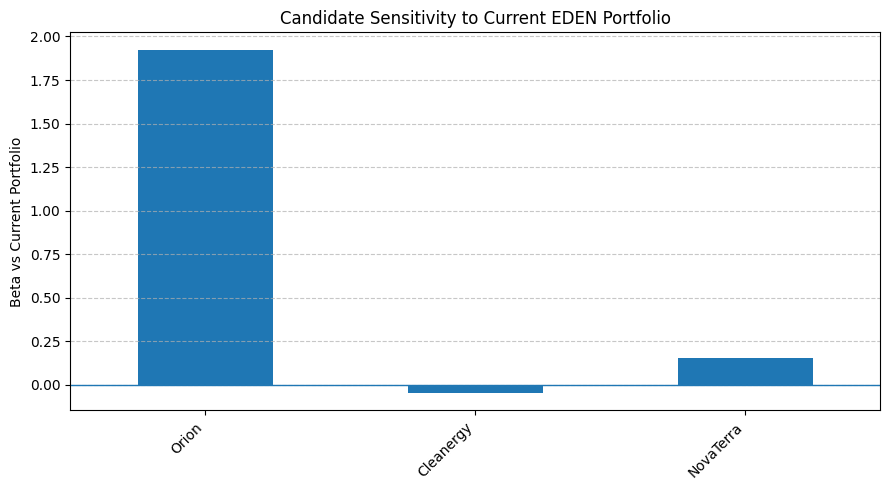

In [17]:
import matplotlib.pyplot as plt

# --- Plot candidate beta versus current EDEN portfolio ---

plot_data = regression_results_df.set_index("Candidate")["Beta vs Current Portfolio"]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Candidate Sensitivity to Current EDEN Portfolio")
plt.ylabel("Beta vs Current Portfolio")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visualizes each candidate's beta versus the current EDEN portfolio. Each bar shows how sensitive the candidate's daily returns have historically been to movements in the existing portfolio. A higher positive beta indicates that the candidate tends to amplify current portfolio movements, while a beta close to zero indicates limited co-movement.

**Chart Interpretation:**
*   **Orion:** Orion has the highest beta, indicating that it behaves like a high-beta extension of the current EDEN portfolio. This weakens its diversification case and supports the concern that it may duplicate existing semiconductor / AI-related exposure.
*   **Cleanergy:** Cleanergy has an approximately zero beta, indicating very limited historical sensitivity to the current portfolio. This suggests independence from the current portfolio, but it does not automatically mean the stock adds value; standalone risk-return quality still needs to be assessed.
*   **NovaTerra:** NovaTerra has a low positive beta, suggesting limited co-movement with the current portfolio and some diversification potential, although the relationship is economically weak.

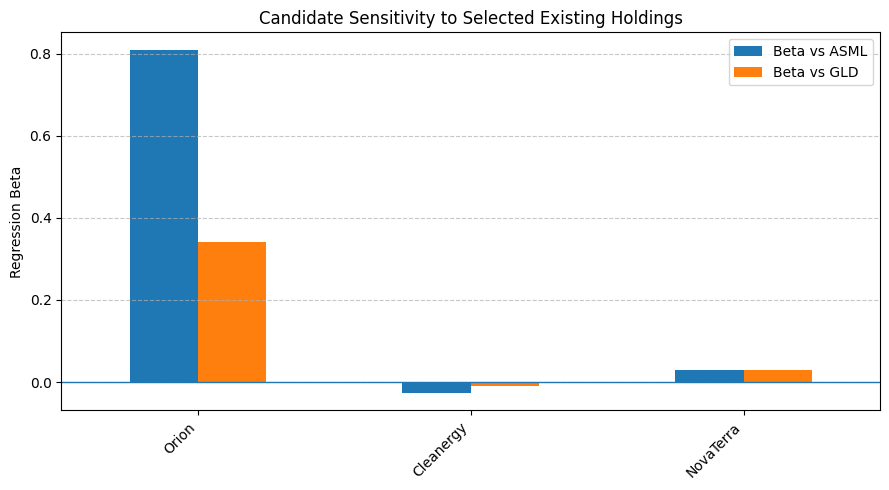

In [18]:
import matplotlib.pyplot as plt

# --- Plot candidate betas versus ASML and GLD ---

plot_data = subset_regression_results_df.set_index("Candidate")[
    ["Beta vs ASML", "Beta vs GLD"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Candidate Sensitivity to Selected Existing Holdings")
plt.ylabel("Regression Beta")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visualizes each candidate's regression beta versus two selected existing EDEN holdings: ASML and GLD. ASML is used as a proxy for semiconductor / AI-capex exposure, while GLD is used as a proxy for gold / defensive real-asset exposure. The chart helps identify whether a candidate is likely to duplicate existing portfolio exposures.

**Chart Interpretation:**
*   **Orion:** Orion shows the strongest sensitivity to ASML and a positive sensitivity to GLD. The high ASML beta suggests that Orion may partially duplicate the portfolio's existing semiconductor / AI-related exposure, weakening its diversification case.
*   **Cleanergy:** Cleanergy has near-zero betas versus both ASML and GLD. This suggests that its historical returns are not meaningfully explained by either the semiconductor/AI exposure or the gold/defensive exposure already present in the portfolio.
*   **NovaTerra:** NovaTerra also shows very low betas versus both ASML and GLD. This indicates limited overlap with these two selected holdings, although its strategic portfolio fit still needs to be assessed separately.

Overall, this chart strengthens the argument that Orion has the clearest overlap with existing EDEN holdings, while Cleanergy and NovaTerra are more independent from the selected portfolio exposures. However, low sensitivity alone does not prove investment attractiveness; it must be combined with standalone risk-return and business-quality evidence.

## Part 2: Scenario Analysis

Here, we demonstrate how scenario analysis can be used to test how each candidate might behave under hypothetical movements in the current EDEN portfolio or selected existing holdings. This is useful for stress-testing candidate sensitivity, but it should not be interpreted as a precise return forecast.

**Steps in Scenario Analysis:**
*   **Input Hypothetical Returns:** Define assumed movements for the current EDEN portfolio or selected holdings such as ASML and GLD.
*   **Apply Regression Model:** Use the fitted OLS coefficients to estimate the implied candidate return under those assumptions.
*   **Scenario Testing:** Compare how Orion, Cleanergy, and NovaTerra respond under the same hypothetical portfolio conditions.
*   **Interpret Results Carefully:** Treat the outputs as sensitivity estimates, not predictions. The regression captures historical co-movement, but it does not fully explain future returns or standalone investment quality.

In [19]:
# --- Scenario analysis using candidate-vs-current-portfolio regression ---

# Hypothetical movements in the current EDEN portfolio
hypothetical_current_portfolio_returns = pd.DataFrame({
    "Scenario": ["Downside case", "Flat case", "Upside case"],
    "Current Portfolio": [-0.02, 0.00, 0.02]
})

scenario_sensitivity_results = []

for _, row in hypothetical_current_portfolio_returns.iterrows():
    scenario_name = row["Scenario"]
    current_portfolio_return = row["Current Portfolio"]

    for _, regression_row in regression_results_df.iterrows():
        candidate = regression_row["Candidate"]
        alpha = regression_row["Alpha Daily"]
        beta = regression_row["Beta vs Current Portfolio"]

        implied_candidate_return = alpha + beta * current_portfolio_return

        scenario_sensitivity_results.append({
            "Scenario": scenario_name,
            "Current Portfolio Return": current_portfolio_return,
            "Candidate": candidate,
            "Implied Candidate Return": implied_candidate_return,
        })

scenario_sensitivity_results_df = pd.DataFrame(scenario_sensitivity_results)

display(scenario_sensitivity_results_df)

,Scenario,Current Portfolio Return,Candidate,Implied Candidate Return
0,Downside case,-0.02,Orion,-0.037410
1,Downside case,-0.02,Cleanergy,0.001461
2,Downside case,-0.02,NovaTerra,-0.002507
3,Flat case,0.00,Orion,0.001090
4,Flat case,0.00,Cleanergy,0.000500
5,Flat case,0.00,NovaTerra,0.000599
6,Upside case,0.02,Orion,0.039589
7,Upside case,0.02,Cleanergy,-0.000460
8,Upside case,0.02,NovaTerra,0.003706


This scenario table illustrates how the regression betas translate into sensitivity under simple hypothetical portfolio moves. Orion amplifies both downside and upside movements because of its high beta. Cleanergy remains close to neutral because its beta is near zero, while NovaTerra shows only mild sensitivity. These outputs are illustrative and should not be interpreted as forecasts.

## Part 3: Correlation Analysis

This section examines the correlation structure between the current EDEN portfolio holdings and the three candidate investments. Correlation analysis helps assess whether a candidate is likely to diversify the portfolio or move in line with existing exposures.

The analysis considers both a static correlation matrix and rolling correlations over time. The static matrix provides a snapshot of average historical co-movement across the full sample, while rolling correlations show whether these relationships are stable or change across market regimes.

**Purpose of Correlation Analysis:**
*   **Diversification:** Identify whether Orion, Cleanergy, or NovaTerra moves closely with the existing EDEN holdings.
*   **Portfolio Overlap:** Assess whether a candidate duplicates existing exposures such as ASML's semiconductor / AI-capex risk or XLU's utilities exposure.
*   **Time Variation:** Test whether correlations are stable over time or only appear during specific market periods.
*   **Decision Support:** Use correlation as one input in the investment recommendation, while recognizing that low correlation alone does not prove that a candidate is attractive.

In [20]:
# --- Correlation between ASML and each candidate ---

candidate_columns = ["Orion", "Cleanergy", "NovaTerra"]

asml_candidate_correlations = (
    asset_returns[["ASML"] + candidate_columns]
    .corr()
    .loc[candidate_columns, ["ASML"]]
    .rename(columns={"ASML": "Correlation with ASML"})
)

display(asml_candidate_correlations)

,Correlation with ASML
Orion,0.535709
Cleanergy,-0.022473
NovaTerra,0.037532


This output shows the historical correlation between ASML and each of the three candidate investments. The purpose is to test whether any candidate appears to overlap with EDEN's existing semiconductor / AI-capex exposure through ASML.

**Observed Results:**
*   **Orion:** Correlation with ASML of approximately 0.536, indicating a moderate positive relationship.
*   **Cleanergy:** Correlation with ASML of approximately -0.022, indicating almost no linear relationship.
*   **NovaTerra:** Correlation with ASML of approximately 0.038, indicating almost no linear relationship.

**Interpretation:**

Orion has the highest correlation with ASML among the three candidates. This supports the concern that Orion may partially duplicate existing semiconductor / AI-related exposure in the portfolio. However, the correlation is moderate rather than extremely high, so the overlap argument should be framed as a risk of partial duplication, not as proof that Orion is identical to ASML.

Cleanergy and NovaTerra show near-zero correlation with ASML. This suggests that they are not materially exposed to the same return pattern as ASML, at least based on historical daily returns. However, low correlation alone does not prove that either candidate is attractive; it only indicates lower overlap with this specific existing holding.

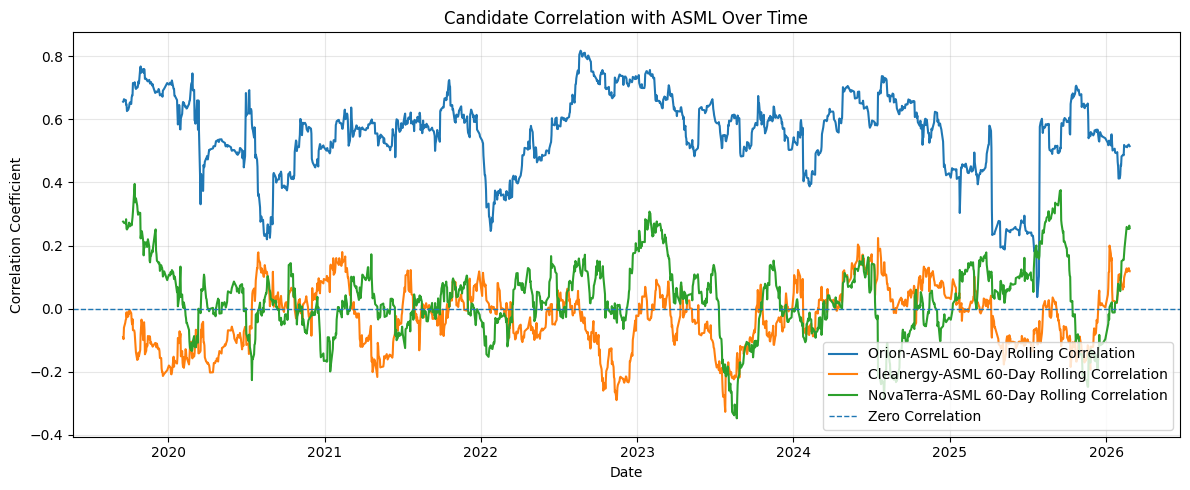

In [21]:
# --- Rolling correlation between each candidate and ASML ---

candidate_columns = ["Orion", "Cleanergy", "NovaTerra"]
rolling_window = 60

rolling_corr_asml = pd.DataFrame(index=asset_returns.index)

for candidate in candidate_columns:
    rolling_corr_asml[candidate] = (
        asset_returns[candidate]
        .rolling(window=rolling_window)
        .corr(asset_returns["ASML"])
    )

plt.figure(figsize=(12, 5))

for candidate in candidate_columns:
    plt.plot(
        rolling_corr_asml.index,
        rolling_corr_asml[candidate],
        label=f"{candidate}-ASML 60-Day Rolling Correlation"
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    label="Zero Correlation"
)

plt.title("Candidate Correlation with ASML Over Time")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The rolling 60-day correlation confirms that Orion is the candidate most consistently linked to ASML. Its correlation remains positive for most of the period and is often materially higher than the correlations of Cleanergy and NovaTerra. This supports the concern that Orion may duplicate existing semiconductor / AI-capex exposure in the EDEN portfolio.

Cleanergy and NovaTerra fluctuate around zero for much of the period, indicating lower and less persistent co-movement with ASML. However, this should be treated as a diversification diagnostic only: low correlation does not automatically imply investment attractiveness.

## Part 4: Monte Carlo Simulation for Portfolio Growth

A Monte Carlo simulation is used to estimate the range of potential one-year outcomes for the current EDEN portfolio and each candidate-addition scenario. Rather than producing a precise forecast, the simulation helps compare downside risk, upside potential, and dispersion across the possible portfolio choices.

For comparability, all scenarios are rebased to a common €40,000 starting value. This means the “Current Portfolio” line should be interpreted as a normalized return comparison, not as the actual pre-allocation market value of the existing portfolio.

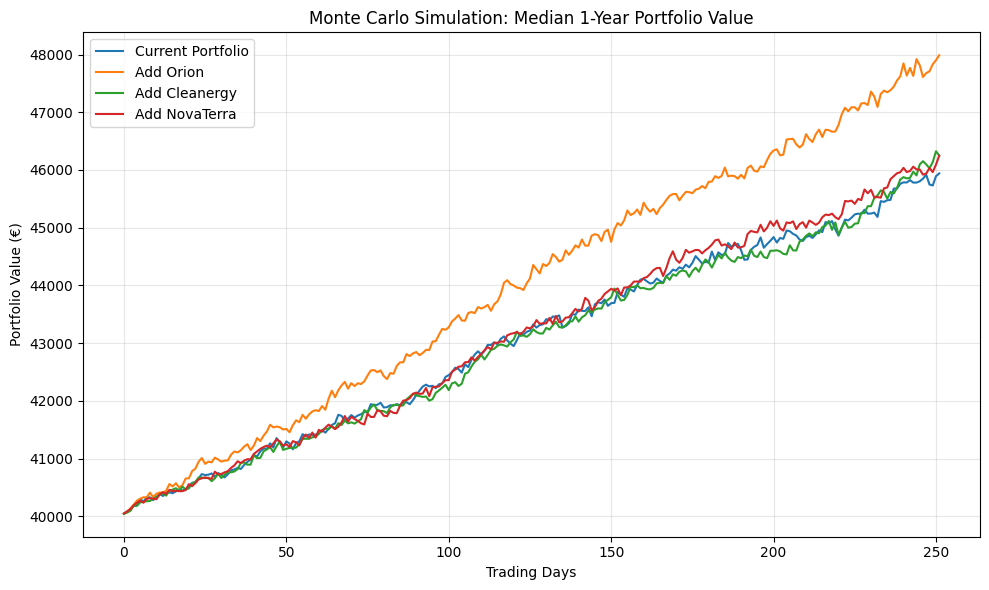

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Monte Carlo Simulation: Current Portfolio vs Candidate Scenarios
# ============================================================

# Configuration
num_simulations = 1000
num_days = 252
initial_value = 40000
random_seed = 42

np.random.seed(random_seed)

# Select scenario return columns
scenario_columns = [
    "Current Portfolio",
    "Add Orion",
    "Add Cleanergy",
    "Add NovaTerra"
]

scenario_data = scenario_returns[scenario_columns].dropna()

# Calculate historical daily mean returns and covariance matrix
mean_returns = scenario_data.mean()
cov_matrix = scenario_data.cov()

# Store simulation outputs
simulation_results = {}

for scenario in scenario_columns:
    simulation_results[scenario] = np.zeros((num_days, num_simulations))

# Run Monte Carlo simulations
for i in range(num_simulations):
    simulated_daily_returns = np.random.multivariate_normal(
        mean_returns,
        cov_matrix,
        num_days
    )

    simulated_daily_returns_df = pd.DataFrame(
        simulated_daily_returns,
        columns=scenario_columns
    )

    for scenario in scenario_columns:
        simulation_results[scenario][:, i] = (
            initial_value
            * np.cumprod(1 + simulated_daily_returns_df[scenario].values)
        )

# ============================================================
# Plot median simulated portfolio value paths
# ============================================================

plt.figure(figsize=(10, 6))

for scenario in scenario_columns:
    median_path = np.percentile(simulation_results[scenario], 50, axis=1)

    plt.plot(
        median_path,
        label=scenario
    )

plt.title("Monte Carlo Simulation: Median 1-Year Portfolio Value")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Monte Carlo Summary Statistics
# ============================================================

monte_carlo_summary = []

for scenario in scenario_columns:
    ending_values = simulation_results[scenario][-1, :]

    monte_carlo_summary.append({
        "Scenario": scenario,
        "Mean Ending Value (€)": ending_values.mean(),
        "Median Ending Value (€)": np.median(ending_values),
        "5th Percentile Ending Value (€)": np.percentile(ending_values, 5),
        "95th Percentile Ending Value (€)": np.percentile(ending_values, 95),
        "Probability of Loss": np.mean(ending_values < initial_value),
        "Probability of >10% Loss": np.mean(ending_values < initial_value * 0.90),
    })

monte_carlo_summary_df = pd.DataFrame(monte_carlo_summary)

display(monte_carlo_summary_df)

,Scenario,Mean Ending Value (€),Median Ending Value (€),5th Percentile Ending Value (€),95th Percentile Ending Value (€),Probability of Loss,Probability of >10% Loss
0,Current Portfolio,46900.482006,45940.071080,33780.638181,63100.656242,0.227,0.102
1,Add Orion,49363.332340,47987.102249,33850.399569,69069.510964,0.196,0.090
2,Add Cleanergy,46766.637385,46248.503717,34255.724078,62021.043097,0.214,0.079
3,Add NovaTerra,46972.746803,46247.892873,35232.420101,62083.621460,0.197,0.068


The Monte Carlo simulation compares the current EDEN portfolio with each candidate-addition scenario over a one-year horizon. The median-path chart shows that **Add Orion** produces the highest central simulated outcome, and the summary table confirms this: Orion has the highest mean ending value (€49,363) and highest median ending value (€47,987).

However, the downside metrics are more mixed. **Add NovaTerra** has the strongest simulated downside profile, with the highest 5th percentile ending value (€35,232), the lowest probability of loss (19.7%, tied closely with Orion at 19.6%), and the lowest probability of a loss greater than 10% (6.8%). **Add Cleanergy** also improves the >10% loss probability versus the current portfolio, reducing it from 10.2% to 7.9%, but it does not improve the median outcome meaningfully relative to NovaTerra or the current portfolio.

Overall, the Monte Carlo output supports **Orion from an upside / median-return perspective**, but not from a diversification perspective. NovaTerra appears more attractive on simulated downside protection, while Cleanergy's Monte Carlo case is weaker because its median and mean outcomes are not materially better than the current portfolio despite its lower co-movement. Therefore, the simulation should be treated as one decision input, not a standalone recommendation: Orion offers the strongest simulated upside, while NovaTerra offers the cleanest simulated downside profile.

## Part 5: Historical Scenario Performance

This section compares how the current EDEN portfolio and each candidate-addition scenario would have evolved historically over the available sample period. Each path is indexed to 100, allowing direct comparison of cumulative performance across scenarios.

This is not a forecast. It is a historical backtest of the same portfolio scenarios used in the Monte Carlo analysis. The purpose is to check whether the simulated results are directionally consistent with historical scenario performance.

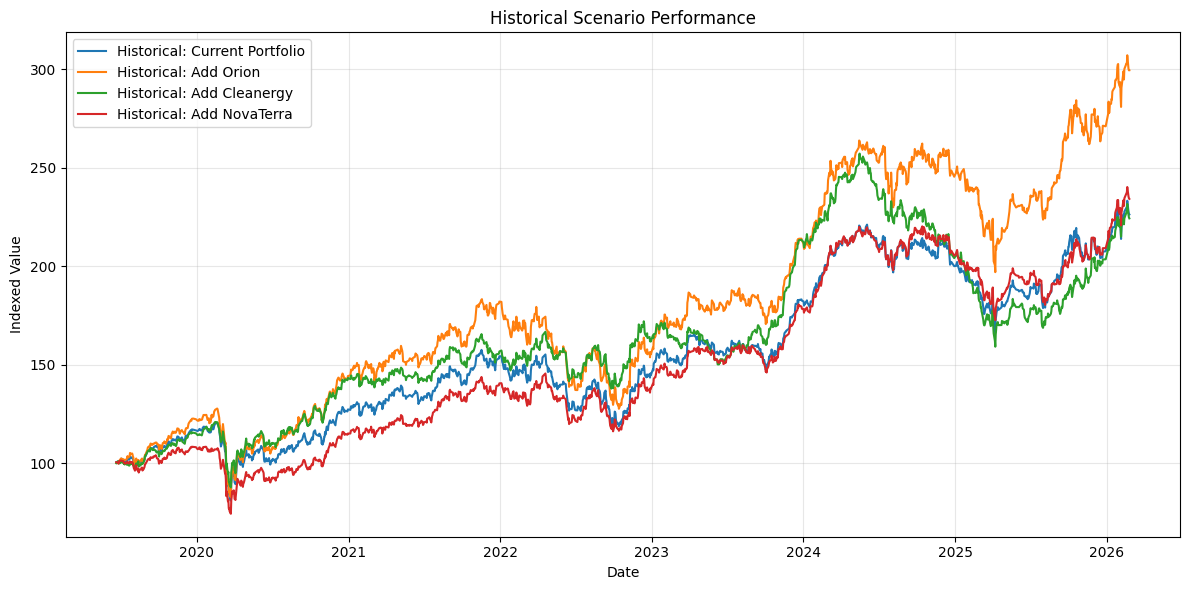

In [25]:
import matplotlib.pyplot as plt

# --- Historical vs simulated median path for candidate-addition scenarios ---

scenario_columns = [
    "Current Portfolio",
    "Add Orion",
    "Add Cleanergy",
    "Add NovaTerra"
]

# Historical cumulative return paths, normalized to 100
historical_indexed = (1 + scenario_returns[scenario_columns]).cumprod() * 100

plt.figure(figsize=(12, 6))

for scenario in scenario_columns:
    plt.plot(
        historical_indexed.index,
        historical_indexed[scenario],
        label=f"Historical: {scenario}"
    )

plt.title("Historical Scenario Performance")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The historical scenario chart compares how the current portfolio and each candidate-addition scenario would have evolved over the available sample period, indexed to 100. The **Add Orion** scenario shows the strongest historical cumulative performance, ending materially above the other scenarios. This supports Orion's return case and is consistent with the Monte Carlo result showing the highest mean and median ending values.

However, the chart also reinforces the trade-off in the recommendation. Orion's stronger historical performance comes alongside higher overlap with ASML and the current portfolio. Cleanergy and NovaTerra are more differentiated, but their historical cumulative performance does not clearly dominate the current portfolio. Therefore, this chart is useful as supporting evidence, but the final decision should still depend on risk-adjusted performance, downside risk, correlation, and fundamental fit.

## Conclusion

This notebook has provided a portfolio-focused analysis of the current EDEN holdings and the three candidate-addition scenarios. The analysis covered candidate sensitivity to the existing portfolio, correlation with key holdings, rolling ASML correlation, historical scenario performance, and Monte Carlo simulation outcomes. Together, these methods help assess both return potential and diversification impact.

The results show a clear trade-off. **Orion** has the strongest historical and simulated return profile, including the highest Monte Carlo mean and median ending values, but it also shows the strongest overlap with ASML and the current portfolio. This weakens its diversification case. **Cleanergy** is more independent from the existing portfolio and aligns better with an energy-transition portfolio gap, but the Monte Carlo and historical scenario results do not show a clear return advantage. **NovaTerra** offers differentiated exposure and the strongest simulated downside profile, but its strategic fit is less direct than Cleanergy's and its upside case is weaker than Orion's.

Overall, the notebook does not produce a single mechanical winner. Instead, it clarifies the investment committee trade-off: Orion offers the strongest return case, Cleanergy offers the clearest thematic portfolio-fit case, and NovaTerra offers the best simulated downside protection. The final recommendation should therefore combine these quantitative findings with the fundamental assessment, EDEN rule compliance, and the desired balance between upside potential and diversification.

## Part 6: Monte Carlo Simulation with Dynamic Volatility (GARCH / EWMA + Student-t Shocks)

This section replicates the Monte Carlo simulation from Part 4 and upgrades it with a **hybrid dynamic-volatility model**. The core limitation of the Part 4 approach is that it fixes both expected returns and the covariance matrix at their full-sample historical averages. In practice, volatility clusters over time: high-volatility periods tend to persist, and shock distributions in equity markets have heavier tails than a normal distribution implies.

The upgrades applied here are:

* **GARCH(1,1) dynamic volatility** (or EWMA fallback if the `arch` package is unavailable): instead of using a single historical standard deviation, we estimate a time-varying conditional volatility for each scenario and use the GARCH-forecast one-step-ahead variance as the starting volatility for simulation.
* **Student-t random shocks**: equity returns exhibit excess kurtosis (fat tails). Replacing Gaussian shocks with Student-t shocks increases the probability of extreme daily moves in the simulation, producing a more realistic tail-risk picture.
* **Conservative blended drift**: rather than using the full historical mean return as the forward drift, we blend the recent 63-day rolling mean with the full-sample mean. This reduces the risk of projecting an unusually strong or weak recent period forward without justification. **This is an assumption, not a forecast.**
* **Dynamic covariance reconstruction**: the historical correlation matrix is preserved, but the per-scenario GARCH/EWMA volatility forecasts replace the historical standard deviations to construct a scenario-specific covariance matrix for each simulation day.

The output structure (`simulation_results`, the median-path chart, and `monte_carlo_summary_df`) is identical to Part 4, so the two sections can be compared directly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Part 6: Hybrid Monte Carlo — GARCH/EWMA + Student-t Shocks
# ============================================================

# --------------- Configuration (same as Part 4) ---------------
num_simulations = 1000
num_days = 252
initial_value = 40000
random_seed = 42

np.random.seed(random_seed)

# Scenario columns — kept identical to Part 4
scenario_columns = [
    "Current Portfolio",
    "Add Orion",
    "Add Cleanergy",
    "Add NovaTerra",
]

scenario_data = scenario_returns[scenario_columns].dropna()

# ================================================================
# WHY WE REPLACE FIXED HISTORICAL VOLATILITY
# ================================================================
# Part 4 used a single covariance matrix estimated from the full
# historical sample.  That matrix assumes volatility is constant
# over time, which contradicts a well-documented empirical fact:
# equity volatility clusters.  After a calm period the model
# underestimates future vol; after a turbulent period it
# overestimates it.  A dynamic model (GARCH or EWMA) conditions
# the starting volatility on the most recent data, making the
# simulation more responsive to the current volatility regime.
# ================================================================

# --------------- Step 1: Try GARCH(1,1), fall back to EWMA ---------------

try:
    from arch import arch_model
    USE_GARCH = True
    print("arch package found — using GARCH(1,1) volatility estimation.")
except ImportError:
    USE_GARCH = False
    print("arch package not available — using EWMA volatility estimation (fallback).")


def estimate_garch_vol(returns_series, horizon=1):
    """
    Fit GARCH(1,1) to a daily returns series (expressed as decimals).
    Returns the one-step-ahead forecast annualised daily volatility.

    WHAT GARCH CONTRIBUTES
    ----------------------
    GARCH(1,1) models today's variance as a weighted sum of:
      - a long-run average variance (omega)
      - the squared shock from yesterday (alpha * epsilon_{t-1}^2)
      - yesterday's conditional variance (beta * sigma_{t-1}^2)
    This means periods of high recent volatility raise the forecast
    variance for the next day, and vice versa.  Compared with a
    single historical variance estimate, the GARCH forecast is
    regime-aware and converges back to the long-run mean over time.
    """
    scaled = returns_series * 100  # arch expects percentage returns
    model = arch_model(scaled, vol="Garch", p=1, q=1, dist="t", rescale=False)
    res = model.fit(disp="off", show_warning=False)
    forecast = res.forecast(horizon=horizon)
    # Convert variance from %-squared back to decimal-squared
    forecast_var = forecast.variance.iloc[-1, 0] / 10_000
    return float(np.sqrt(forecast_var))


def estimate_ewma_vol(returns_series, lam=0.94):
    """
    Estimate current volatility using an Exponentially Weighted Moving
    Average (EWMA / RiskMetrics) model.

    EWMA assigns exponentially declining weights to past squared returns,
    so recent observations matter more than older ones.  Lambda=0.94 is
    the RiskMetrics daily decay factor: it gives the equivalent of roughly
    a 16-day effective window, making it more responsive than a full-sample
    standard deviation but smoother than a very short rolling window.
    """
    sq_returns = returns_series ** 2
    ewma_var = sq_returns.ewm(alpha=(1 - lam), adjust=False).mean().iloc[-1]
    return float(np.sqrt(ewma_var))


# Estimate dynamic daily volatility for each scenario
dynamic_vols = {}

for scenario in scenario_columns:
    series = scenario_data[scenario].dropna()
    if USE_GARCH:
        dynamic_vols[scenario] = estimate_garch_vol(series)
    else:
        dynamic_vols[scenario] = estimate_ewma_vol(series)

print("\nDynamic one-step-ahead daily volatility estimates:")
for scenario, vol in dynamic_vols.items():
    print(f"  {scenario}: {vol:.4%} per day  ({vol * np.sqrt(252):.4%} annualised)")

# ================================================================
# WHY STUDENT-t SHOCKS ARE USED
# ================================================================
# Normal (Gaussian) shocks assign near-zero probability to moves
# larger than ~3 standard deviations.  In reality, equity markets
# experience 4-6 sigma moves far more often than the normal
# distribution predicts (fat tails / leptokurtosis).  A Student-t
# distribution with low degrees of freedom (e.g. 5–8) produces
# heavier tails, meaning extreme daily losses and gains are more
# likely in simulation.  This gives a more realistic picture of
# tail risk and avoids systematic understatement of downside
# scenarios.
# ================================================================

# Estimate degrees of freedom for the Student-t distribution
# by fitting to the pooled scenario return distribution.
pooled_returns = scenario_data.values.flatten()
pooled_returns = pooled_returns[~np.isnan(pooled_returns)]
_, df_t, _ = stats.t.fit(pooled_returns)
df_t = max(df_t, 4.0)  # cap minimum at 4 to avoid undefined variance
print(f"\nStudent-t degrees of freedom (fitted): {df_t:.2f}")

# ================================================================
# CONSERVATIVE BLENDED DRIFT ASSUMPTION
# ================================================================
# Using the full historical mean daily return as the forward drift
# implicitly assumes that the recent performance period will repeat.
# If the sample includes an unusually strong or weak stretch, this
# biases the projection.  We instead blend the recent 63-day rolling
# mean (one quarter) with the full-sample mean using equal weights.
# This dampens extreme recent drift while still acknowledging
# long-run historical tendencies.
#
# IMPORTANT: This blended drift is an assumption, not a forecast.
# It is used solely to provide a plausible central tendency for the
# simulation.  The actual future return could be materially higher
# or lower.
# ================================================================

recent_window = 63  # ~1 quarter of trading days

blended_mean_returns = {}

for scenario in scenario_columns:
    series = scenario_data[scenario].dropna()
    long_term_mean = series.mean()
    recent_mean = series.tail(recent_window).mean()
    blended = 0.5 * long_term_mean + 0.5 * recent_mean
    blended_mean_returns[scenario] = blended

blended_mean_series = pd.Series(blended_mean_returns, name="Blended Mean Return")
print("\nBlended drift estimates (assumption, not a forecast):")
print(blended_mean_series.map("{:.6f}".format).to_string())

# ================================================================
# DYNAMIC COVARIANCE MATRIX
# ================================================================
# Correlation captures the co-movement pattern between scenarios.
# We preserve the historical correlation matrix (which is relatively
# stable) but replace the per-scenario variances with the
# GARCH/EWMA volatility forecasts.  This gives a covariance matrix
# that is correlated in the same historical proportions but scaled
# to current volatility levels rather than the long-run average.
#
# ASSUMPTIONS THAT REMAIN
# -----------------------
# 1. Correlations are assumed constant at their historical levels.
#    In stress events, correlations often rise sharply (contagion).
# 2. The drift (expected return) is a blended assumption, not a
#    model-based forecast.  Simulated paths are sensitive to drift.
# 3. GARCH/EWMA forecasts reflect recent data; they do not
#    anticipate structural breaks or regime changes.
# 4. Student-t degrees of freedom are estimated from history and
#    may not reflect the severity of future tail events.
# ================================================================

# Historical correlation matrix (normalised, shape-preserving)
corr_matrix = scenario_data.corr().values

# Reconstruct dynamic covariance matrix from GARCH/EWMA vols
vol_vector = np.array([dynamic_vols[s] for s in scenario_columns])
dynamic_cov_matrix = np.outer(vol_vector, vol_vector) * corr_matrix

# Ensure the covariance matrix is positive semi-definite
# (numerical issues can occasionally break this for small samples)
min_eigenvalue = np.linalg.eigvalsh(dynamic_cov_matrix).min()
if min_eigenvalue < 0:
    dynamic_cov_matrix += (-min_eigenvalue + 1e-8) * np.eye(len(scenario_columns))

# Cholesky decomposition for correlated sampling
L = np.linalg.cholesky(dynamic_cov_matrix)

print("\nDynamic covariance matrix (using GARCH/EWMA vols + historical correlations):")
print(pd.DataFrame(dynamic_cov_matrix, index=scenario_columns, columns=scenario_columns).round(8).to_string())


In [ ]:
# ============================================================
# Run Hybrid Monte Carlo Simulation
# ============================================================
# Instead of drawing from a multivariate normal, we:
#   1. Draw independent standard Student-t shocks for each scenario.
#   2. Correlate them using the Cholesky factor of the dynamic
#      covariance matrix (which already encodes scale via vols).
#   3. Add the blended drift to each day's shock.
# This preserves cross-scenario correlations while using fat-tailed
# shocks and dynamic volatility scaling.
# ============================================================

np.random.seed(random_seed)

# Store simulation outputs — same structure as Part 4
simulation_results = {}

for scenario in scenario_columns:
    simulation_results[scenario] = np.zeros((num_days, num_simulations))

drift_vector = np.array([blended_mean_returns[s] for s in scenario_columns])

for i in range(num_simulations):
    # Draw independent t-distributed shocks (zero mean, unit scale)
    # shape: (num_days, num_scenarios)
    raw_shocks = stats.t.rvs(df=df_t, size=(num_days, len(scenario_columns)))

    # Rescale shocks to unit variance so the covariance scaling via L is correct
    # (Student-t with df has variance df/(df-2); we normalise to variance 1)
    raw_shocks /= np.sqrt(df_t / (df_t - 2))

    # Apply Cholesky factor to introduce cross-scenario correlations and vol scaling
    correlated_shocks = raw_shocks @ L.T  # shape: (num_days, num_scenarios)

    # Add blended drift
    daily_returns = correlated_shocks + drift_vector  # broadcast over days

    simulated_returns_df = pd.DataFrame(daily_returns, columns=scenario_columns)

    for scenario in scenario_columns:
        simulation_results[scenario][:, i] = (
            initial_value
            * np.cumprod(1 + simulated_returns_df[scenario].values)
        )

# ============================================================
# Plot median simulated portfolio value paths
# ============================================================

plt.figure(figsize=(10, 6))

for scenario in scenario_columns:
    median_path = np.percentile(simulation_results[scenario], 50, axis=1)
    plt.plot(median_path, label=scenario)

vol_method = "GARCH(1,1)" if USE_GARCH else "EWMA"
plt.title(
    f"Part 6: Monte Carlo Simulation — Median 1-Year Portfolio Value\n"
    f"({vol_method} dynamic volatility + Student-t shocks, blended drift)"
)
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Monte Carlo Summary Statistics
# Same structure as Part 4 for direct comparison
# ============================================================

monte_carlo_summary = []

for scenario in scenario_columns:
    ending_values = simulation_results[scenario][-1, :]

    monte_carlo_summary.append({
        "Scenario": scenario,
        "Mean Ending Value (€)": ending_values.mean(),
        "Median Ending Value (€)": np.median(ending_values),
        "5th Percentile Ending Value (€)": np.percentile(ending_values, 5),
        "95th Percentile Ending Value (€)": np.percentile(ending_values, 95),
        "Probability of Loss": np.mean(ending_values < initial_value),
        "Probability of >10% Loss": np.mean(ending_values < initial_value * 0.90),
    })

monte_carlo_summary_df = pd.DataFrame(monte_carlo_summary)

display(monte_carlo_summary_df)


### Part 6 Interpretation: Dynamic Volatility and Fat-Tailed Simulation

The results above are produced by a hybrid Monte Carlo model that replaces the fixed historical covariance matrix from Part 4 with **dynamic volatility estimates** (GARCH(1,1) if available, otherwise EWMA) and **Student-t random shocks** to capture fat tails.

**Key differences from Part 4:**

* **Dynamic volatility:** The per-scenario variance used in simulation is conditioned on the most recent data rather than averaged across the full sample. If the most recent period was calmer than average, the dynamic model will produce tighter simulated distributions than Part 4; if it was more volatile, the distributions will be wider. This makes the simulation more responsive to the current volatility regime.
* **Student-t shocks:** The heavier tails of the t-distribution increase the simulated frequency of large single-day moves relative to the normal distribution. This typically widens the gap between the 5th and 95th percentile ending values and raises the estimated probability of loss, even if the median path is similar.
* **Blended drift:** The expected daily return used as the simulation drift is a 50/50 blend of the recent 63-day mean and the full-sample historical mean. This is an assumption, not a forecast. It is designed to avoid over-anchoring on an unusually strong or weak recent period.

**What has not changed:**

* Correlations between scenarios are still taken from the historical correlation matrix and are assumed to remain constant. In a stress event, correlations between equity-like scenarios often rise, which would worsen downside outcomes relative to what the model shows.
* The simulation captures statistical risk, not fundamental or event risk. A regulatory change, a credit event, or a macro shock that is not in the historical data will not appear in the simulated paths.

**Conclusion:** This model provides a more realistic characterisation of tail risk and volatility dynamics than the Part 4 baseline. However, all Monte Carlo simulations depend on assumptions. The results should be treated as a structured scenario comparison, not a precise forecast of future portfolio values.